In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

df = pd.read_csv('../data/ChatGPT_cleaned.csv', low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)

Task was destroyed but it is pending!
task: <Task pending name='Task-96' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /home/falko/TER/venv/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-97' coro=<_async_in_context.<locals>.preserve_context() running at /home/falko/TER/venv/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/falko/TER/venv/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.10/xml/etree/ElementTree.py:580: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  self._root = parser._parse_whole(source)
Task was destroyed but it is pending!
task: <Task pending name='Task-97' coro=<_async_in_context.<locals>.preserve_context() running at /home/falko/TER/venv/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]>
[nltk_data] Downloading pack

Shape: (476193, 14)


,Unnamed: 0,Date,Tweet,Url,User,UserCreated,UserVerified,UserFollowers,UserFriends,Retweets,Likes,Location,Description,cleaned_tweet
0,0,2023-04-08 03:33:13+00:00,#ChatGPT If only there were a movie or somethi...,https://twitter.com/kirbydjohnson/status/16445...,kirbydjohnson,2012-07-29 22:57:46+00:00,False,50.0,76.0,0,0,NaN,NaN,movie show end
1,1,2023-04-08 03:32:16+00:00,"Workshop Description: In this workshop, you wi...",https://twitter.com/UniversityWeb/status/16445...,UniversityWeb,2013-01-13 20:18:16+00:00,False,9056.0,387.0,0,0,NaN,"University webinars, speech videos, & news for...",workshop description workshop learn use advanc...
2,2,2023-04-08 03:32:05+00:00,New Post at AiNewsDrop!\n\nChatGPT is a doctor...,https://twitter.com/AiNewsDrop/status/16445436...,AiNewsDrop,2022-01-19 06:25:45+00:00,False,276.0,313.0,0,0,NaN,I'm up almost 24/7 hunting for AI News\n\nWith...,new post ainewsdrop doctor sorta artificial in...


In [6]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == '':
        return 'neutral'
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

def get_compound_score(text):
    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    return sia.polarity_scores(text)['compound']

print("Annotating sentiments...")
df['sentiment'] = df['Tweet'].apply(get_sentiment)
df['compound_score'] = df['Tweet'].apply(get_compound_score)
print("Done ✓")

Annotating sentiments...
Done ✓


sentiment
positive    249982
neutral     150924
negative     75287
Name: count, dtype: int64

Positive: 52.5%
Negative: 15.8%
Neutral : 31.7%


/tmp/ipykernel_22519/1944011181.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['green', 'gray', 'red'])


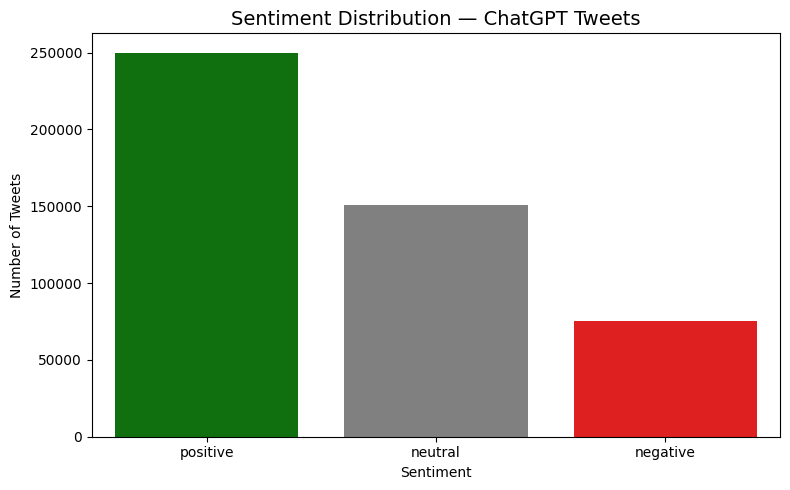

In [7]:
counts = df['sentiment'].value_counts()
print(counts)
print(f"\nPositive: {counts.get('positive',0)/len(df)*100:.1f}%")
print(f"Negative: {counts.get('negative',0)/len(df)*100:.1f}%")
print(f"Neutral : {counts.get('neutral',0)/len(df)*100:.1f}%")

plt.figure(figsize=(8, 5))
sns.barplot(x=counts.index, y=counts.values, palette=['green', 'gray', 'red'])
plt.title('Sentiment Distribution — ChatGPT Tweets', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('../figures/03_sentiment_distribution.png', dpi=150)
plt.show()

In [8]:
df.to_csv('../data/ChatGPT_annotated.csv', index=False)
print("Saved to data/ChatGPT_annotated.csv ✓")

Saved to data/ChatGPT_annotated.csv ✓
